# Quora Duplicate Question Detection

## BERT-Based Models

This notebook contains experiments with BERT-based approaches for duplicate
question detection:

1. Pretrained BERT embeddings with cosine similarity.
2. Fine-tuned BERT for binary sequence-pair classification.

## Project Setup and Imports

In [ ]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    pass

In [ ]:
# Colab only: uncomment when running the notebook in Google Colab
# %cd "/content/drive/MyDrive/ML Projects/quora-duplicate-question-detection"

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: g:\My Drive\ML Projects\quora-duplicate-question-detection


In [ ]:
import os

import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

from src.config import (
    feature_file,
    processed_train_file,
    results_file,
)
from src.evaluation import (
    evaluate_binary_classifier,
    save_experiment_result,
)

## Data Loading

The preprocessed training dataset and the original train-validation split are
loaded from the files created in `01_data_preparation_eda.ipynb`.

In [5]:
df = pd.read_parquet(processed_train_file)

train_mask = df["split"].eq("train")
valid_mask = df["split"].eq("valid")

train_data = df.loc[train_mask].copy()
valid_data = df.loc[valid_mask].copy()

y_train = train_data["is_duplicate"].astype(int)
y_valid = valid_data["is_duplicate"].astype(int)

print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)

Train shape: (258743, 11)
Validation shape: (64686, 11)


In [6]:
assert df["id"].is_unique
assert df["split"].notna().all()
assert set(df["split"]) == {"train", "valid"}
assert len(train_data) + len(valid_data) == len(df)

print("Preprocessed data loaded successfully.")

Preprocessed data loaded successfully.


## Experiment 1: Pretrained BERT Embeddings and Cosine Similarity

In this experiment, the pretrained `bert-base-uncased` model is used as a
feature extractor. Question embeddings are obtained using mean pooling, and
cosine similarity is used to classify question pairs.

The BERT model is not fine-tuned in this experiment.

### Load Saved BERT Cosine Similarity

The BERT embeddings and cosine similarity values were previously calculated
and saved. The saved rows are checked against the current dataset before the
feature is attached.

In [7]:
bert_features = pd.read_csv(feature_file)

assert len(bert_features) == len(df)

for column in ["question1", "question2"]:
    saved_values = (
        bert_features[column]
        .fillna("")
        .astype(str)
        .reset_index(drop=True)
    )

    current_values = (
        df[column]
        .fillna("")
        .astype(str)
        .reset_index(drop=True)
    )

    assert saved_values.equals(current_values)

assert np.array_equal(
    bert_features["is_duplicate"].to_numpy(),
    df["is_duplicate"].to_numpy(),
)

df["bert_cosine_similarity"] = (
    bert_features["bert_cosine_similarity"].to_numpy()
)

print("Saved BERT cosine similarity loaded successfully.")

Saved BERT cosine similarity loaded successfully.


### Threshold Selection and Model Evaluation

The classification threshold is selected using only the training split.
The selected threshold is then applied to the validation split.

In [8]:
train_scores = df.loc[train_mask, "bert_cosine_similarity"]
valid_scores = df.loc[valid_mask, "bert_cosine_similarity"]

In [9]:
best_threshold = None
best_f1 = -1

for threshold in np.arange(0.1, 1.0, 0.01):
    train_preds = (
        train_scores >= threshold
    ).astype(int)

    current_f1 = f1_score(
        y_train,
        train_preds,
    )

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

print(
    f"Best threshold from train: "
    f"{best_threshold:.2f}"
)

print(
    f"Train F1 at best threshold: "
    f"{best_f1:.4f}"
)

Best threshold from train: 0.83
Train F1 at best threshold: 0.6425


Model: BERT Embeddings + Cosine Similarity

              precision    recall  f1-score   support

           0     0.8630    0.5315    0.6578     40804
           1     0.5167    0.8559    0.6444     23882

    accuracy                         0.6513     64686
   macro avg     0.6899    0.6937    0.6511     64686
weighted avg     0.7352    0.6513    0.6529     64686

accuracy: 0.6513
precision: 0.5167
recall: 0.8559
f1: 0.6444
roc_auc: 0.7455


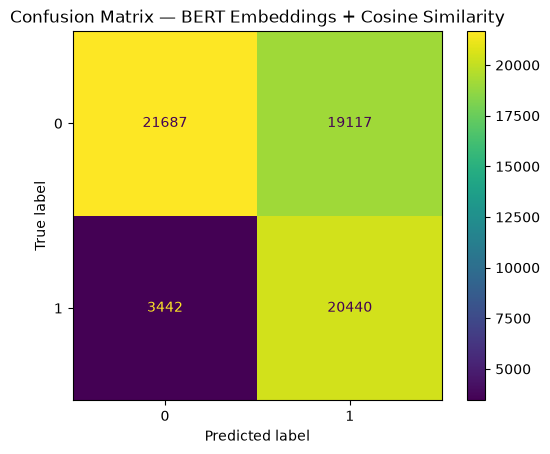

In [10]:
valid_preds = (valid_scores >= best_threshold).astype(int)

bert_metrics = evaluate_binary_classifier(
    model_name="BERT Embeddings + Cosine Similarity",
    y_true=y_valid,
    y_pred=valid_preds,
    y_score=valid_scores,
)

### Conclusions

- Mean-pooled embeddings from the pretrained `bert-base-uncased` model capture
  part of the semantic similarity between questions.
- A classification threshold of **0.83** was selected using only the training
  split.
- On the validation split, the approach achieved a ROC-AUC of approximately
  **0.75** and an F1-score of approximately **0.64**.
- Recall is high at approximately **0.86**, meaning that most duplicate
  question pairs are identified.
- Precision is considerably lower at approximately **0.52**, indicating that
  many non-duplicate pairs are incorrectly classified as duplicates.

## Experiment Results

The validation metrics are added to the shared project results table.
Re-running the same experiment replaces its previous result instead of
creating a duplicate row.

Log loss is not reported for this experiment because cosine similarity is a
ranking score rather than a predicted class probability.

In [11]:
bert_result_row = {
    "experiment_id": "bert_mean_pooling_cosine",
    "evaluation_split": "validation",
    "feature_set": (
        "Mean-pooled bert-base-uncased embeddings "
        "+ cosine similarity"
    ),
    "threshold": float(best_threshold),
    **bert_metrics,
    "log_loss": np.nan,
}

model_results = save_experiment_result(
    result_row=bert_result_row,
    results_file=results_file,
)

Results saved to: g:\My Drive\ML Projects\quora-duplicate-question-detection\reports\model_results.csv


In [12]:
model_results_display = (
    model_results.copy()
)

numeric_columns = (
    model_results_display
    .select_dtypes(include="number")
    .columns
)

model_results_display[
    numeric_columns
] = model_results_display[
    numeric_columns
].round(4)

display(
    model_results_display.sort_values(
        by="log_loss"
    )
)

,experiment_id,evaluation_split,feature_set,threshold,model,accuracy,precision,recall,f1,roc_auc,log_loss
0,tfidf_logreg_baseline,validation,TF-IDF word 1-2 grams: absolute difference + e...,0.50,TF-IDF + Logistic Regression,0.8253,0.8005,0.7017,0.7478,0.9039,0.3893
1,xgboost_engineered_features,validation,14 symmetric lexical and length features + TF-...,0.50,XGBoost + Engineered Features,0.7643,0.6700,0.7122,0.6905,0.8529,0.4371
2,bert_mean_pooling_cosine,validation,Mean-pooled bert-base-uncased embeddings + cos...,0.83,BERT Embeddings + Cosine Similarity,0.6513,0.5167,0.8559,0.6444,0.7455,NaN


## Optional Appendix: Regenerate BERT Embeddings

> **This section is disabled during normal notebook execution.**
>
> The embeddings and cosine similarity values have already been calculated and
> saved. Run this section only when the embedding cache must be rebuilt or new
> questions must be processed.
>
> Google Colab with GPU is recommended.

In [21]:
REGENERATE_BERT_FEATURES = False

print(
    "BERT feature regeneration:",
    REGENERATE_BERT_FEATURES,
)

BERT feature regeneration: False


When running this section in Google Colab for the first time, install the
required libraries:

```python
%pip install transformers torch --quiet
```

### Initialize BERT Model

In [ ]:
if REGENERATE_BERT_FEATURES:
    import pickle

    import torch
    from tqdm.auto import tqdm
    from transformers import BertModel, BertTokenizer

    from sklearn.metrics.pairwise import cosine_similarity
    from src.config import cache_file, chunks_dir

    bert_tokenizer = BertTokenizer.from_pretrained(
        "bert-base-uncased"
    )

    bert_model = BertModel.from_pretrained(
        "bert-base-uncased"
    )

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    bert_model = bert_model.to(device)
    bert_model.eval()

    print("Device:", device)
else:
    print("Skipped: BERT regeneration is disabled.")

### Collect Unique Questions and Load the Embedding Cache

This section collects all unique questions from the processed dataset and
loads the existing embedding cache from the configured project storage.

If the main cache does not exist, an empty cache is initialized. Existing
chunk files are also loaded so that processing can resume after an interrupted
runtime.

In [ ]:
if REGENERATE_BERT_FEATURES:
    questions = (
        pd.concat(
            [
                df["question1"],
                df["question2"],
            ],
            ignore_index=True,
        )
        .fillna("")
        .astype(str)
        .drop_duplicates()
        .reset_index(drop=True)
    )

    if os.path.exists(cache_file):
        with open(cache_file, "rb") as file:
            embedding_dict = pickle.load(file)

        print(
            f"Loaded {len(embedding_dict):,} embeddings "
            "from the main cache."
        )
    else:
        embedding_dict = {}
        print("Creating a new embedding cache.")

    if os.path.exists(chunks_dir):
        chunk_files = sorted(
            filename
            for filename in os.listdir(chunks_dir)
            if filename.startswith("chunk_")
            and filename.endswith(".pkl")
        )

        for filename in chunk_files:
            chunk_path = os.path.join(
                chunks_dir,
                filename,
            )

            with open(chunk_path, "rb") as file:
                embedding_dict.update(
                    pickle.load(file)
                )

        print(
            f"Loaded {len(chunk_files)} chunk files."
        )

    print(
        f"Unique questions: {len(questions):,}"
    )

    print(
        f"Total available embeddings: "
        f"{len(embedding_dict):,}"
    )

else:
    print("Skipped: embedding cache was not loaded.")

### Compute Missing Embeddings Only

Only questions that are absent from the existing cache are processed.
New embeddings are saved in chunk files to prevent progress loss if the
runtime disconnects.

In [ ]:
if REGENERATE_BERT_FEATURES:

    def get_sentence_embeddings_batch(
        texts,
        max_length=128,
    ):
        texts = [str(text) for text in texts]

        inputs = bert_tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        with torch.no_grad():
            outputs = bert_model(**inputs)

        last_hidden_states = (
            outputs.last_hidden_state
        )

        attention_mask = inputs[
            "attention_mask"
        ]

        mask_expanded = (
            attention_mask
            .unsqueeze(-1)
            .expand(last_hidden_states.size())
            .float()
        )

        embeddings = (
            torch.sum(
                last_hidden_states * mask_expanded,
                dim=1,
            )
            / torch.clamp(
                mask_expanded.sum(dim=1),
                min=1e-9,
            )
        )

        return embeddings.cpu().numpy()

In [ ]:
if REGENERATE_BERT_FEATURES:
    questions_to_process = [
        question
        for question in questions
        if question not in embedding_dict
    ]

    print(
        "Questions to process:",
        len(questions_to_process),
    )

In [ ]:
if REGENERATE_BERT_FEATURES:
    os.makedirs(chunks_dir, exist_ok=True)

    batch_size = 64
    chunk_size = 5000

    existing_chunk_ids = [
        int(
            filename
            .removeprefix("chunk_")
            .removesuffix(".pkl")
        )
        for filename in os.listdir(chunks_dir)
        if filename.startswith("chunk_")
        and filename.endswith(".pkl")
    ]

    chunk_id = max(existing_chunk_ids, default=-1) + 1
    current_chunk = {}

    for batch_start in tqdm(range(0, len(questions_to_process), batch_size)):
        batch_questions = questions_to_process[batch_start:batch_start + batch_size]

        batch_embeddings = get_sentence_embeddings_batch(batch_questions)

        for question, embedding in zip(batch_questions, batch_embeddings):
            embedding_dict[question] = embedding
            current_chunk[question] = embedding

        if len(current_chunk) >= chunk_size:
            chunk_path = os.path.join(chunks_dir, f"chunk_{chunk_id}.pkl")

            with open(chunk_path, "wb") as f:
                pickle.dump(current_chunk, f)

            print(f"Saved {chunk_path} with {len(current_chunk)} embeddings")

            current_chunk = {}
            chunk_id += 1

    if len(current_chunk) > 0:
        chunk_path = os.path.join(chunks_dir, f"chunk_{chunk_id}.pkl")

        with open(chunk_path, "wb") as f:
            pickle.dump(current_chunk, f)

        print(f"Saved final {chunk_path} with {len(current_chunk)} embeddings")

In [ ]:
if REGENERATE_BERT_FEATURES:
    with open(cache_file, "wb") as file:
        pickle.dump(embedding_dict, file)

    print(
        f"Main cache updated: "
        f"{len(embedding_dict):,} embeddings"
    )

### Recompute and Save Cosine Similarity

This cell rebuilds the cosine similarity feature from the embedding cache.
It should be run only after confirming that every question has an embedding.

In [ ]:
if REGENERATE_BERT_FEATURES:

    missing_questions = [
        question
        for question in questions
        if question not in embedding_dict
    ]

    if missing_questions:
        raise RuntimeError(
            f"{len(missing_questions)} questions "
            "do not have embeddings."
        )

    def cosine_similarity_embeddings(
        embedding_1,
        embedding_2,
    ):
        return cosine_similarity(
            embedding_1.reshape(1, -1),
            embedding_2.reshape(1, -1),
        )[0, 0]

    tqdm.pandas()

    df["bert_cosine_similarity"] = (
        df.progress_apply(
            lambda row: cosine_similarity_embeddings(
                embedding_dict[
                    str(row["question1"])
                ],
                embedding_dict[
                    str(row["question2"])
                ],
            ),
            axis=1,
        )
    )

    df[
        [
            "question1",
            "question2",
            "is_duplicate",
            "bert_cosine_similarity",
        ]
    ].to_csv(
        feature_file,
        index=False,
    )

    print(
        "Saved cosine similarity feature to:",
        feature_file,
    )
else:
    print("Skipped: cosine similarity was not recomputed.")